In [11]:
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
import cutde.halfspace as HS
import geopandas as gpd
import os

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

In [12]:
## From matlab
# For dip rotation
def rotx(matrix, alpha):
    alpha = np.radians(alpha)
    rot_mat = np.array([[1, 0, 0],
                        [0, np.cos(alpha), -np.sin(alpha)],
                        [0, np.sin(alpha), np.cos(alpha)]])

    return np.matmul(rot_mat, matrix.T).T

def roty(matrix, beta):
    beta = np.radians(beta)
    rot_mat = np.array([[np.cos(beta), 0, np.sin(beta)],
                        [0, 1, 0],
                        [-np.sin(beta), 0, np.cos(beta)]])

    return np.matmul(rot_mat, matrix.T).T

# For strike rotation
def rotz(matrix, gamma):
    gamma = np.radians(gamma)
    rot_mat = np.array([[np.cos(gamma), -np.sin(gamma), 0],
                        [np.sin(gamma), np.cos(gamma), 0],
                        [0, 0, 1]])

    return np.matmul(rot_mat, matrix.T).T

In [13]:
def cross_3d(a, b):
    """
    Calculates cross product of two 3-dimensional vectors.
    """
    x = ((a[1] * b[2]) - (a[2] * b[1]))
    y = ((a[2] * b[0]) - (a[0] * b[2]))
    z = ((a[0] * b[1]) - (a[1] * b[0]))
    return np.array([x, y, z])

def check_triangle_normal(triangle_vertices):
    """ needed for correct dip direction. check if the normal vector is positive or negative. If negative,
    flip the order of the vertices. Triangle_vertices is a 3x3 array of the vertices of the triangle (3 vertices,
    each with xyz)"""

    vector_a = triangle_vertices[1] - triangle_vertices[0]
    vector_b = triangle_vertices[1] - triangle_vertices[2]
    cross_a_b_vector = cross_3d(vector_a, vector_b)
    # Ensure that normal always points down (for proper strike convention), if not, flip the order of the vertices
    # this results in greens functions where dip slip is reverse motion, which is what we want (positive rake).
    if cross_a_b_vector[-1] > 0:
        ordered_triangle_vertices = triangle_vertices[-1::-1]
        print('flip', triangle_vertices, 'to', ordered_triangle_vertices)
    else:
        ordered_triangle_vertices = triangle_vertices
    return ordered_triangle_vertices

In [14]:
def fault_bearing(linestring, strike):
    start = np.array(linestring.coords[0])
    end = np.array(linestring.coords[-1])
    delta = end - start
    bearing = np.degrees(np.arctan2(delta[0], delta[1]))
    bearing = bearing % 360
    if np.abs(bearing - strike) < 90:
        reference_coords = linestring.coords[0]
    else:
        reference_coords = linestring.coords[-1]
    return bearing, reference_coords

In [15]:
def calc_tde_dims(tde_size, tde_height, tri_type):
    if tde_size != 0:
        if 'right' in tri_type.lower():
            tde_height = tde_size
        else:
            tde_height = np.sqrt(tde_size**2 - (tde_size / 2)**2)
    else:
        if 'right' in tri_type.lower():
            tde_size = tde_height
        else:
            tde_size = tde_height / np.sin(np.radians(60))
    return tde_size, tde_height

In [ ]:
crustal_fault_model = "NZSHM22_InversionSolution-QXV0b21hdGlvblRhc2s6MTA3MDA2"
fault_name = "Edgecumbe"
dip_addition = 0

bend_dips_arr = [65, 50, 35]  # Keep empty for CFM dip
bend_dips_arr = []
bend_depth_arr = [1, 2, 6]  # Lower edges of each section
CFM_seismo_lim = False  # True if you want to limit the depth of the CFM

tde_size = 3
tde_height = 0
ss = 0
ds = -1
obs_res = 0.1
obs_buffer = 20
strike = 0
tri_type = 'eqi'  # 'right' or 'equilateral'

In [17]:
if CFM_seismo_lim or len(bend_dips_arr) > 0:
    assert len(bend_depth_arr) > 0, 'CFM_seismo_lim taken from end of bend_depth_arr'
    seismo_depth = bend_depth_arr[-1]
else:
    seismo_depth = None

if len(bend_dips_arr) == 0:
    if seismo_depth is None:
        png_name = f'{fault_name}_CFMdip_{tde_size:.2f}km_{"right" if "right" in tri_type.lower() else "equi"}-tde'
    else:
        png_name = f'{fault_name}_CFMdip-{seismo_depth:.0f}kmSeismo_{tde_size:.2f}km_{"right" if "right" in tri_type.lower() else "equi"}-tde'
else:
    assert len(bend_dips_arr) == len(bend_depth_arr), "bend_dips_arr and bend_depth_arr must be the same length"
    png_name = f'{fault_name}_{"-".join([f"{dip:.0f}-{bend_depth:.0f}km" for dip, bend_depth in zip(bend_dips_arr, bend_depth_arr)])}_{tde_size:.2f}km_{"right" if "right" in tri_type.lower() else "equi"}-tde'

print(png_name)

# Identify fault sections
fault_polys = gpd.read_file(os.path.join("data", "crustal_solutions", crustal_fault_model, "ruptures", "fault_sections.geojson")).to_crs(epsg=2193)
fault_polys = fault_polys[fault_polys['FaultName'].str.contains(fault_name)]

# Obs grid
obs_res *= 1e3
obs_buffer *= 1e3
min_lon, max_lon = fault_polys.geometry.bounds.minx.min(), fault_polys.geometry.bounds.maxx.max()
min_lat, max_lat = fault_polys.geometry.bounds.miny.min(), fault_polys.geometry.bounds.maxy.max()
lons = np.arange(np.floor((min_lon - obs_buffer) / 10e3) * 10e3, np.ceil((max_lon + obs_buffer) / 10e3) * 10e3, obs_res)
lats = np.arange(np.floor((min_lat - obs_buffer) / 10e3) * 10e3, np.ceil((max_lat + obs_buffer) / 10e3) * 10e3, obs_res)

lon_grid, lat_grid = np.meshgrid(lons, lats)
obs_points = np.vstack((lon_grid.ravel(), lat_grid.ravel(), np.zeros_like(lon_grid.ravel()))).T

Edgecumbe_CFMdip_3.00km_equi-tde


Edgecumbe 1987, Subsection 0: dip=50, top_depth=0.00, base_depth=11.61, width=15.150, tde_size=3.000, tde_height=2.598
Edgecumbe 1987, Subsection 1: dip=50, top_depth=0.00, base_depth=11.61, width=15.150, tde_size=3.000, tde_height=2.598
Edgecumbe 1987, Subsection 2: dip=50, top_depth=0.00, base_depth=11.61, width=15.150, tde_size=3.000, tde_height=2.598
Edgecumbe Coastal, Subsection 0: dip=50, top_depth=0.00, base_depth=11.41, width=14.889, tde_size=3.000, tde_height=2.598
Edgecumbe Coastal, Subsection 1: dip=50, top_depth=0.00, base_depth=11.41, width=14.889, tde_size=3.000, tde_height=2.598


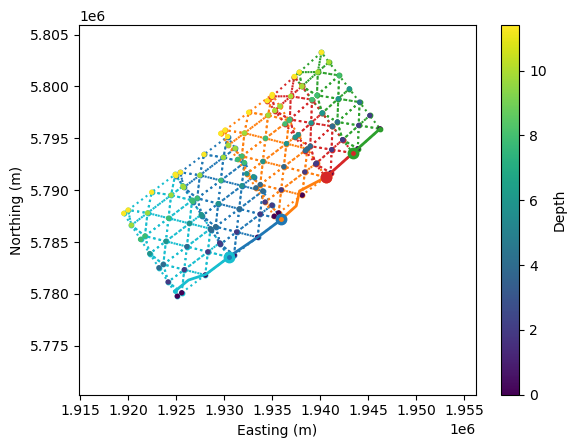

In [18]:
dips = []
strikes = []
coords = np.array([]).reshape(-1, 3)
triangles = np.array([]).reshape(-1, 3, 3)
default_tde_size, default_tde_height = calc_tde_dims(tde_size, tde_height, tri_type)
bend_depth_arr.append(np.inf)

plot_structure = True

for idx, row in fault_polys.iterrows():
    bend_depth_tmp = bend_depth_arr.copy()
    bend_dips_tmp = bend_dips_arr.copy()
    if len(bend_dips_tmp) == 0:
        dip = row['DipDeg'] + dip_addition
        bend_depth = np.inf
    else:
        dip = bend_dips_tmp.pop(0)
        bend_depth = bend_depth_tmp.pop(0)

    strike = row['DipDir'] - 90
    top_depth = row['UpDepth']
    bottom_depth = row['LowDepth'] if seismo_depth is None else seismo_depth
    base_depth = bend_depth if bottom_depth > bend_depth else bottom_depth

    ## Calculate shallow portion of the fault
    width = (base_depth - top_depth) / np.sin(np.radians(dip))
    if width < default_tde_height:
        tde_size, tde_height = calc_tde_dims(0, width, tri_type)
    else:
        tde_size, tde_height = default_tde_size, default_tde_height
    print(f"{row.FaultName}: dip={dip:.0f}, top_depth={top_depth:.2f}, base_depth={base_depth:.2f}, width={width:.3f}, tde_size={tde_size:.3f}, tde_height={tde_height:.3f}")
    length = row.geometry.length / 1000
    rowy_0 = np.unique(np.append(np.arange(0, length, tde_size), length))
    if 'right' in tri_type.lower():
        rowy_1 = rowy_0
    else:
        rowy_1 = np.unique(np.append(np.arange(tde_size / 2, length, tde_size), np.array([0, length])))
    rowy_1 = np.unique(np.append(np.arange(tde_size / 2, length, tde_size), np.array([0, length])))
    rowx = np.unique(np.append(np.arange(0, width, tde_height), width))

    patch_coords = np.array([]).reshape(-1, 3)
    for ix, x in enumerate(rowx):
        if ix % 2 == 0:
            ycol = rowy_0
        else:
            ycol = rowy_1
        coords_row = np.vstack((np.ones_like(ycol) * x, ycol, np.zeros_like(ycol))).T
        patch_coords = np.vstack((patch_coords, coords_row))
    join_point = patch_coords.shape[0] - len(ycol)

    mesh = Delaunay(patch_coords[:, :2]).simplices

    patch_coords = roty(patch_coords, dip)
    patch_coords[:, 2] -= top_depth
    patch_coords *= 1e3

    # plt.triplot(patch_coords[:, 0], patch_coords[:, 1], mesh, zorder=10)

    while bottom_depth > bend_depth:
        dip = bend_dips_tmp.pop(0)
        btm_coords = np.array([]).reshape(-1, 3)
        base_depth, top_depth = bend_depth_tmp[0], bend_depth
        width = (base_depth - top_depth) / np.sin(np.radians(dip))
        if width < default_tde_height:
            tde_size, tde_height = calc_tde_dims(0, width, tri_type)
        else:
            tde_size, tde_height = default_tde_size, default_tde_height
        print(f"{row.FaultName}: dip={dip:.0f}, top_depth={top_depth:.2f}, base_depth={base_depth:.2f}, width={width:.3f}, tde_size={tde_size:.3f}, tde_height={tde_height:.3f}")
        rowy_0 = np.unique(np.append(np.arange(0, length, tde_size), length))
        if 'right' in tri_type.lower():
            rowy_1 = rowy_0
        else:
            rowy_1 = np.unique(np.append(np.arange(tde_size / 2, length, tde_size), np.array([0, length])))
        rowy_1 = np.unique(np.append(np.arange(tde_size / 2, length, tde_size), np.array([0, length])))
        rowx = np.unique(np.append(np.arange(0, width, tde_height), width))
        for bix, x in enumerate(rowx, ix):
            print(bix, x, ix)
            if bix == ix: # Use the previous ycol (allows for a change in TDE size)
                n_drop = len(ycol)
            else:
                if bix % 2 == 0:
                    ycol = rowy_0
                else:
                    ycol = rowy_1
            coords_row = np.vstack((np.ones_like(ycol) * x, ycol, np.zeros_like(ycol))).T
            btm_coords = np.vstack((btm_coords, coords_row))

        btm_mesh = Delaunay(btm_coords[:, :2]).simplices

        btm_coords = roty(btm_coords, dip)
        btm_coords[:, 2] -= bend_depth
        btm_coords *= 1e3

        mesh = np.vstack((mesh, btm_mesh + join_point))
        patch_coords = np.vstack((patch_coords[:join_point, :], btm_coords + np.array([patch_coords[-1, 0], 0, 0])))
        bend_depth = bend_depth_tmp.pop(0)
        join_point = patch_coords.shape[0] - len(ycol)

        # plt.triplot(btm_coords[:, 0], btm_coords[:, 1], btm_mesh, zorder=10)
    
    patch_coords = rotz(patch_coords, -strike)
    bearing, reference_coords = fault_bearing(row.geometry, strike)
    patch_coords += np.array([reference_coords[0], reference_coords[1], 0])
    coords = np.vstack((coords, patch_coords))
    patch_triangles = patch_coords[mesh]
    triangles = np.vstack((triangles, patch_triangles))

    if plot_structure:
        plt.scatter(patch_coords[:, 0], patch_coords[:, 1], c=colors[idx % len(colors)], s=10, zorder=2)
        for triangle in patch_triangles:
            plt.plot(triangle[[0, 1, 2, 0], 0], triangle[[0, 1, 2, 0], 1], ':', color=colors[idx % len(colors)], zorder=1)
        plt.scatter(patch_coords[:, 0], patch_coords[:, 1], c=patch_coords[:, 2] * -1e-3, s=8, zorder=3)
        plt.plot(row.geometry.xy[0], row.geometry.xy[1], color=colors[idx % len(colors)], linewidth=2, zorder=4)
        plt.plot(row.geometry.xy[0][-1], row.geometry.xy[1][-1], '.', markersize=15, color=colors[idx % len(colors)], zorder=5)
        plt.plot(row.geometry.xy[0][0], row.geometry.xy[1][0], '.', markersize=5, color=colors[idx % len(colors)], zorder=6)

plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')  
if plot_structure:    
    plt.colorbar(label='Depth')
    buffer = 10e3
    plt.xlim([min_lon - buffer, max_lon + buffer])
    plt.ylim([min_lat - buffer, max_lat + buffer])
    plt.savefig(f'{png_name.replace(fault_name, f"{fault_name}_struct")}.png', dpi=300) 
plt.show()

In [19]:
slip_array = np.tile(np.array([ss, ds, 0]), triangles.shape[0]).reshape(-1, 3)
print(f"{triangles.shape[0]} TDEs slipping with ss={ss} m, ds={ds} m")
disp = HS.disp_free(obs_pts=obs_points, tris=triangles, slips=slip_array, nu=0.25)


156 TDEs slipping with ss=0 m, ds=-1 m


c:\Users\jmc753\AppData\Local\anaconda3\envs\jack\lib\site-packages\cutde\coordinators.py:77: UserWarning: The obs_pts input array has Fortran ordering. Converting to C ordering. This may be expensive.
  warnings.warn(
c:\Users\jmc753\AppData\Local\anaconda3\envs\jack\lib\site-packages\cutde\coordinators.py:68: UserWarning: The slips input array has type int32 but needs to be converted to dtype float64. Converting slips to float64 may be expensive.
  warnings.warn(


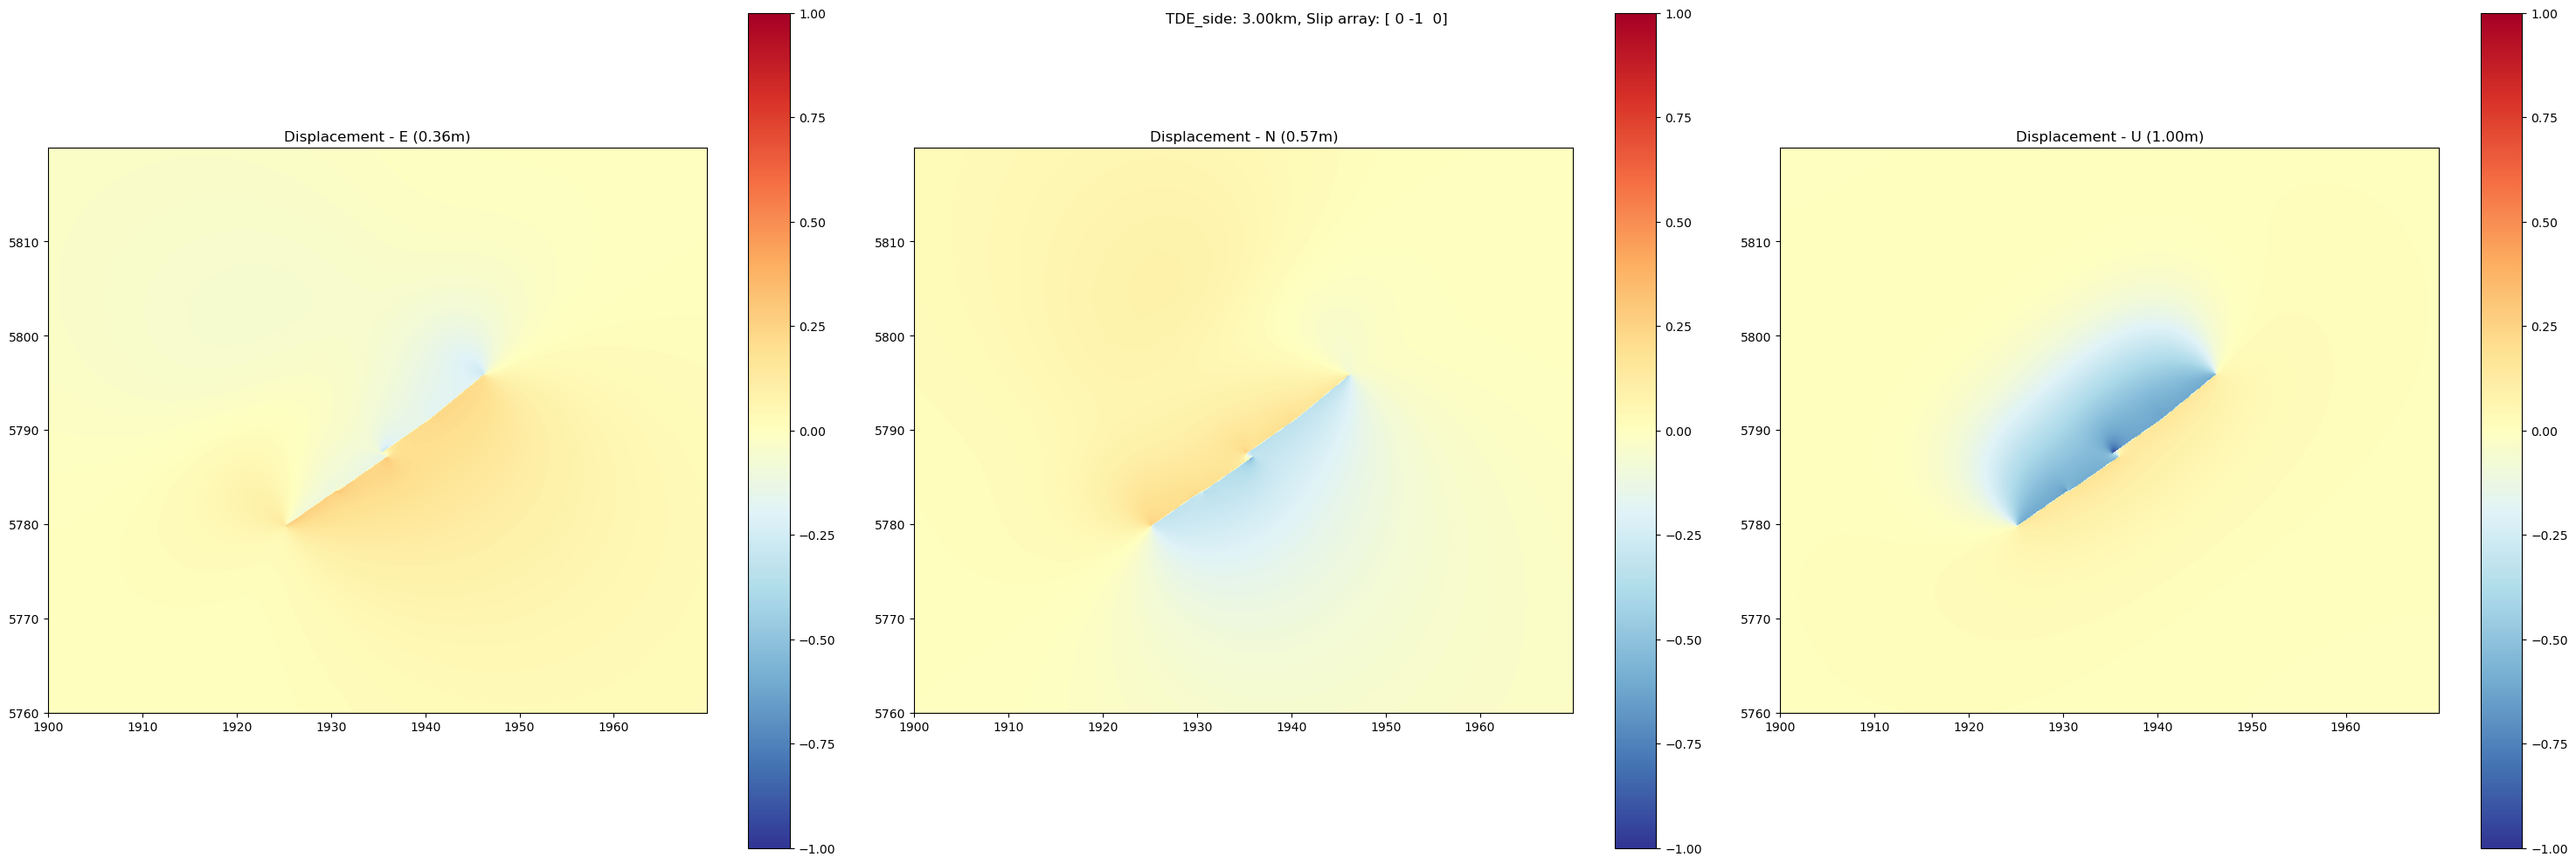

Saved: Edgecumbe_CFMdip_3.00km_equi-tde.png


In [20]:
fig, axes = plt.subplots(1,3, figsize=(30, 10))

abs_disp = np.abs(np.where(np.isnan(disp), 0, disp)[:,:])
vmax = max([np.percentile(abs_disp[abs_disp > 0.1], 99.9), 1.0])
for ix, (ax, label) in enumerate(zip(axes, ['E', 'N', 'U'])):
    disp_array = disp[:, ix].reshape(lon_grid.shape)
    disp_array = np.where(np.isnan(disp_array), 0, disp_array)

    im = ax.imshow(disp_array, extent=(lons.min() / 1e3, lons.max() / 1e3, lats.min() / 1e3, lats.max() / 1e3), vmin=-vmax, vmax=vmax, origin='lower', cmap='RdYlBu_r')
    fig.colorbar(im, ax=ax)
    ax.set_title(f'Displacement - {label} ({np.abs(disp_array).max():.2f}m)')

    nan_points = np.where(np.isnan(disp[:, ix].reshape(lon_grid.shape)))
    if len(nan_points[0]) > 0:
        plt.plot(lon_grid[nan_points] / 1e3, lat_grid[nan_points] / 1e3, 'gx', markersize=5)



plt.tight_layout()

plt.suptitle(f"TDE_side: {tde_size:.2f}km, Slip array: {slip_array[0]}\n")
plt.savefig(f'{png_name}.png', dpi=300) 
plt.show()

print(f'Saved: {png_name}.png')